# Step 1: Inspecting the Raw Data.

## 1. Import Libraries & Load Data

In [53]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Load CSV using the PyArrow engine
df = pd.read_csv("data/NIBRSPublicView2025.csv", engine="pyarrow")

## 2. Check Dimensions & Datatypes

In [54]:
# Display rows, columns, and memory usage
initial_shape = df.shape
print("Dataset Shape:", initial_shape)

# View data types and non-null counts
df.info()

Dataset Shape: (240696, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240696 entries, 0 to 240695
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Incident           240696 non-null  int64  
 1   Occurrence Date    240696 non-null  object 
 2   Occurrence Hour    240696 non-null  int64  
 3   NIBRS Class        240696 non-null  object 
 4   NIBRS Description  240696 non-null  object 
 5   Offense Count      240696 non-null  int64  
 6   Beat               240520 non-null  object 
 7   Premise            240696 non-null  object 
 8   Street Number      239754 non-null  object 
 9   Street Name        240696 non-null  object 
 10  Street Type        222742 non-null  object 
 11  Street Suffix      35839 non-null   object 
 12  City               240696 non-null  object 
 13  ZIP Code           236592 non-null  object 
 14  Map Longitude      237011 non-null  float64
 15  Map Latitude       2370

## 3. Inspect Sample Rows

In [55]:
# Preview first 5 rows
print(df.head())

# Preview a random sample of 5 rows
print(df.sample(5))

   Incident Occurrence Date  Occurrence Hour NIBRS Class  \
0  37542125        1/1/2025                0         13C   
1  37542125        1/1/2025                0         90J   
2  84089625        1/1/2025                0         26F   
3   6608325        1/1/2025                0         13C   
4   6608325        1/1/2025                0         23H   

           NIBRS Description  Offense Count        Beat  \
0               Intimidation              1   Beat 7C30   
1  Trespass of real property              1   Beat 7C30   
2             Identify theft              1  Beat 20G10   
3               Intimidation              2  Beat 18F60   
4          All other larceny              1  Beat 18F60   

                                Premise Street Number Street Name Street Type  \
0                     Hotel, Motel, ETC          3800     TIDWELL          RD   
1                     Hotel, Motel, ETC          3800     TIDWELL          RD   
2                        Other, Unknown  

## 4. Check Missing Values, Duplicate Incidents, and Unique Counts

### Duplicate Incidents

In [56]:
# Find all rows where the 'Incident' value appears more than once
duplicate_incidents = df[df.duplicated(subset=['Incident'], keep=False)]

# Sort by Incident so matching incidents appear right next to each other
duplicate_incidents = duplicate_incidents.sort_values(by='Incident')

# View the first 10 duplicate rows
duplicate_incidents.head(10)

,Incident,Occurrence Date,Occurrence Hour,NIBRS Class,NIBRS Description,Offense Count,Beat,Premise,Street Number,Street Name,Street Type,Street Suffix,City,ZIP Code,Map Longitude,Map Latitude
29,8625,1/1/2025,0,13A,Aggravated Assault,1,Beat 3B10,"Residence, Home (Includes Apartment)",4601,SHERWOOD,LN,None,HOUSTON,77092,-95.458005,29.814084
30,8625,1/1/2025,0,35A,"Drug, narcotic violations",1,Beat 3B10,"Residence, Home (Includes Apartment)",4601,SHERWOOD,LN,None,HOUSTON,77092,-95.458005,29.814084
38,25525,1/1/2025,0,90C,Disorderly conduct,1,Beat 4F20,"Residence, Home (Includes Apartment)",3130,CRESTDALE,DR,None,HOUSTON,77080,-95.530964,29.821344
39,25525,1/1/2025,0,520,Weapon law violations,1,Beat 4F20,"Residence, Home (Includes Apartment)",3130,CRESTDALE,DR,None,HOUSTON,77080,-95.530964,29.821344
240599,28526,12/31/2025,21,290,"Destruction, damage, vandalism",1,Beat 1A10,"Parking Lot, Garage",1501,CAROLINE,ST,None,HOUSTON,77002,-95.365343,29.751575
240600,28526,12/31/2025,21,23F,Theft from motor vehicle,1,Beat 1A10,"Parking Lot, Garage",1501,CAROLINE,ST,None,HOUSTON,77002,-95.365343,29.751575
45,32625,1/1/2025,0,90C,Disorderly conduct,1,Beat 22B30,"Hotel, Motel, ETC",6,SAM HOUSTON,PKWY,N,HOUSTON,77060,-95.410859,29.939923
46,32625,1/1/2025,0,520,Weapon law violations,1,Beat 22B30,"Hotel, Motel, ETC",6,SAM HOUSTON,PKWY,N,HOUSTON,77060,-95.410859,29.939923
47,34925,1/1/2025,0,520,Weapon law violations,1,Beat 5F30,"Residence, Home (Includes Apartment)",6969,HOLLISTER,ST,None,HOUSTON,77040,-95.505434,29.861757
48,34925,1/1/2025,0,90C,Disorderly conduct,1,Beat 5F30,"Residence, Home (Includes Apartment)",6969,HOLLISTER,ST,None,HOUSTON,77040,-95.505434,29.861757


In [57]:
# Find rows where all columns are identical
fully_duplicated_rows = df[df.duplicated(keep=False)]

print(f"Number of completely identical duplicate rows: {len(fully_duplicated_rows)}")

# View a few if any exist
if len(fully_duplicated_rows) > 0:
    print(fully_duplicated_rows.head())

Number of completely identical duplicate rows: 0


In [58]:
# Summary table for missing values and unique entries
summary_df = pd.DataFrame(
    {
        "Missing Values": df.isnull().sum(),
        "Percent Missing": (df.isnull().sum() / len(df)) * 100,
        "Unique Values": df.nunique(),
        "Data Type": df.dtypes,
    }
)
print(summary_df)

                   Missing Values  Percent Missing  Unique Values Data Type
Incident                        0         0.000000         212002     int64
Occurrence Date                 0         0.000000            365    object
Occurrence Hour                 0         0.000000             24     int64
NIBRS Class                     0         0.000000             60    object
NIBRS Description               0         0.000000             60    object
Offense Count                   0         0.000000             13     int64
Beat                          176         0.073121            137    object
Premise                         0         0.000000             46    object
Street Number                 942         0.391365          12725    object
Street Name                     0         0.000000           9594    object
Street Type                 17954         7.459202             32    object
Street Suffix              204857        85.110264              4    object
City        

## 5. Quick Visual Inspection (Missing Data Map)

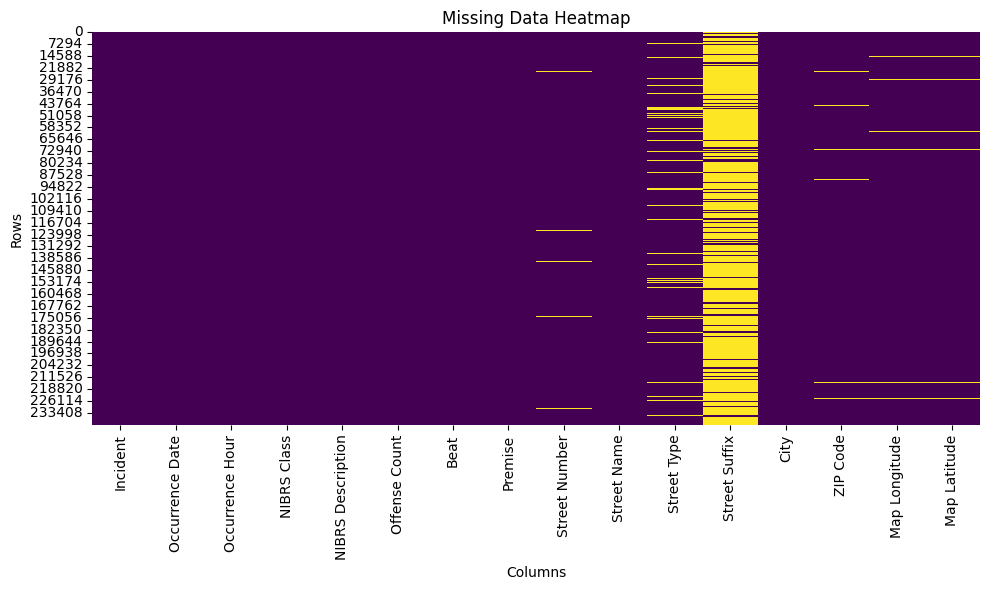

In [59]:
# Visualize missing values using seaborn
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Data Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()

# Step 2: Clean Column Names & Standardize Data Types

## 1. Clean Column Names (lowercase, replace spaces with underscores)

In [60]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
print(df.columns)

Index(['incident', 'occurrence_date', 'occurrence_hour', 'nibrs_class',
       'nibrs_description', 'offense_count', 'beat', 'premise',
       'street_number', 'street_name', 'street_type', 'street_suffix', 'city',
       'zip_code', 'map_longitude', 'map_latitude'],
      dtype='object')


## 2. Standardize Data Types

### Verify memory usage and shape

In [61]:
initial_rows, initial_cols = df.shape
print(df.shape)

(240696, 16)


In [62]:
df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240696 entries, 0 to 240695
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   incident           240696 non-null  int64  
 1   occurrence_date    240696 non-null  object 
 2   occurrence_hour    240696 non-null  int64  
 3   nibrs_class        240696 non-null  object 
 4   nibrs_description  240696 non-null  object 
 5   offense_count      240696 non-null  int64  
 6   beat               240520 non-null  object 
 7   premise            240696 non-null  object 
 8   street_number      239754 non-null  object 
 9   street_name        240696 non-null  object 
 10  street_type        222742 non-null  object 
 11  street_suffix      35839 non-null   object 
 12  city               240696 non-null  object 
 13  zip_code           236592 non-null  object 
 14  map_longitude      237011 non-null  float64
 15  map_latitude       237011 non-null  float64
dtypes:

In [63]:
old_mem_mb = df.memory_usage(deep=True) / (1024**2)
print(old_mem_mb)

Index                 0.000126
incident              1.836365
occurrence_date      13.299484
occurrence_hour       1.836365
nibrs_class          11.936371
nibrs_description    15.926297
offense_count         1.836365
beat                 13.447413
premise              17.368575
street_number        12.165932
street_name          13.059652
street_type          11.313392
street_suffix         6.397741
city                 12.857491
zip_code             12.278136
map_longitude         1.836365
map_latitude          1.836365
dtype: float64


### 2. Convert dates to datetime objects. Parse dates into 8-byte timestamps.

In [64]:
df["occurrence_date"] = pd.to_datetime(df["occurrence_date"], format="%m/%d/%Y")

### 3. Downcast small integers to 1-byte int8

In [65]:
df["occurrence_hour"] = df["occurrence_hour"].astype("int8")
df["offense_count"] = df["offense_count"].astype("int8")

### 4. Downcast coordinates to 4-byte float32

In [66]:
df["map_longitude"] = df["map_longitude"].astype("float32")
df["map_latitude"] = df["map_latitude"].astype("float32")

### 5. Convert categorical text fields to categories

In [67]:
cat_cols = [
    "nibrs_class",
    "nibrs_description",
    "beat",
    "premise",
    "street_name",
    "street_type",
    "street_suffix",
    "city",
    "zip_code",
]
for col in cat_cols:
    df[col] = df[col].astype("category")

### 6. Keep IDs and street numbers as strings

In [68]:
df["incident"] = df["incident"].astype(str)
df["street_number"] = df["street_number"].astype(str)

### Verify updated memory usage and shape

In [69]:
optimized_rows, optimized_cols = df.shape
print(df.shape)

(240696, 16)


In [70]:
new_mem_mb = df.memory_usage(deep=True) / (1024**2)
print(new_mem_mb)

Index                 0.000126
incident             13.164186
occurrence_date       1.836365
occurrence_hour       0.229546
nibrs_class           0.234528
nibrs_description     0.235520
offense_count         0.229546
beat                  0.470726
premise               0.233602
street_number        12.191984
street_name           1.244649
street_type           0.232155
street_suffix         0.229900
city                  0.470168
zip_code              0.477636
map_longitude         0.918182
map_latitude          0.918182
dtype: float64


In [71]:
total_old = old_mem_mb.sum()
total_new = new_mem_mb.sum()
total_pct = ((total_new - total_old) / total_old) * 100

print("\n--- Overall Summary ---")
print(f"Old Memory: {total_old:.2f} MB")
print(f"New Memory: {total_new:.2f} MB")
print(f"Total Change: {total_pct:.2f}%")


--- Overall Summary ---
Old Memory: 149.23 MB
New Memory: 33.32 MB
Total Change: -77.67%


In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240696 entries, 0 to 240695
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   incident           240696 non-null  object        
 1   occurrence_date    240696 non-null  datetime64[ns]
 2   occurrence_hour    240696 non-null  int8          
 3   nibrs_class        240696 non-null  category      
 4   nibrs_description  240696 non-null  category      
 5   offense_count      240696 non-null  int8          
 6   beat               240520 non-null  category      
 7   premise            240696 non-null  category      
 8   street_number      240696 non-null  object        
 9   street_name        240696 non-null  category      
 10  street_type        222742 non-null  category      
 11  street_suffix      35839 non-null   category      
 12  city               240696 non-null  category      
 13  zip_code           236592 non-null  category

# Step 3: Handle Missing Values & Categorical Nulls

## 1. Fill missing text and categorical location fields

In [73]:
# 1. Add 'Unknown' to the category list, then fill NA
df['zip_code'] = df['zip_code'].cat.add_categories('Unknown').fillna('Unknown')
df['beat'] = df['beat'].cat.add_categories('Unknown').fillna('Unknown')

# 2. Leave Map Latitude and Longitude as NaN, but note how many are missing
print(f"Missing coordinates: {df['map_latitude'].isnull().sum()} rows")

Missing coordinates: 3685 rows


## 2. Check remaining missing values

In [74]:
print(df.isnull().sum())

incident                  0
occurrence_date           0
occurrence_hour           0
nibrs_class               0
nibrs_description         0
offense_count             0
beat                      0
premise                   0
street_number             0
street_name               0
street_type           17954
street_suffix        204857
city                      0
zip_code                  0
map_longitude          3685
map_latitude           3685
dtype: int64


# Step 4: Standardizing Text & Trimming Whitespace

## List of text columns to standardize

In [75]:
text_cols = [
    "nibrs_description",
    "premise",
    "street_name",
    "street_type",
    "street_suffix",
    "city",
]

## 1. Strip whitespace and convert to UPPERCASE across text columns

In [76]:
import numpy as np

# 1. Clean up strings, but explicitly turn any variant of blank/nan into true NaN first
for col in text_cols:
    # Strip whitespace, uppercase, and map text variations of missing to actual NaN
    cleaned = df[col].astype(str).str.strip().str.upper()
    cleaned = cleaned.replace(['NAN', 'NAT', 'NONE', 'NULL', ''], np.nan)
    
    # Assign back and convert to category (pandas category handles NaN automatically)
    df[col] = cleaned.astype('category')

## 2. Standardize string IDs and street numbers

In [77]:
df["incident"] = df["incident"].str.strip()
df["street_number"] = df["street_number"].str.strip()

## 3. Verify clean categories

In [78]:
print("Unique Cities:", df["city"].unique().tolist()[:10])
print("Unique Street Types:", df["street_type"].unique().tolist()[:10])

Unique Cities: ['HOUSTON', 'HARRIS CO', 'CR', 'U', 'STAFFORD', 'MISSOURI CITY', 'BELLAIRE', 'BAYTOWN', 'FO', 'KINGWOOD']
Unique Street Types: ['RD', 'BLVD', 'DR', 'WAY', 'ST', 'AVE', 'TRL', 'LN', 'FWY', nan]


# Step 5: Deduplication & Outlier Removal

## 1. Remove Exact Duplicate Rows

In [79]:
initial_rows = len(df)
df = df.drop_duplicates()
dedup_rows = len(df)
print(f"Removed {initial_rows - dedup_rows} exact duplicate rows.")

Removed 0 exact duplicate rows.


## 2. Filter Invalid Geographical Coordinates (Houston bounding box)
### Houston roughly falls between Lat 29.0 to 30.5 and Long -96.0 to -94.5

In [80]:
valid_geo = (
    (df["map_latitude"].between(29.0, 30.5))
    & (df["map_longitude"].between(-96.0, -94.5))
) | (df["map_latitude"].isna())  # Retain explicit NaNs for now

df = df[valid_geo]

## 3. Sanity Check Numeric Outliers
### Ensure offense_count > 0 and occurrence_hour is between 0 and 23

In [81]:
valid_numeric = (df["offense_count"] > 0) & (
    df["occurrence_hour"].between(0, 23)
)
df = df[valid_numeric]

## Rename specific columns

In [82]:
df = df.rename(
    columns={
        "occurrence_date": "date",
        "occurrence_hour": "hour",
        "nibrs_class": "crime_code",
        "nibrs_description": "crime_description",
    }
)

# Verify the updated columns
print(df.columns)

Index(['incident', 'date', 'hour', 'crime_code', 'crime_description',
       'offense_count', 'beat', 'premise', 'street_number', 'street_name',
       'street_type', 'street_suffix', 'city', 'zip_code', 'map_longitude',
       'map_latitude'],
      dtype='object')


# Step 7: Final Verification & File Export

## 1. Final Row Count

In [83]:
print(f"Final cleaned row count: {len(df):,}")

Final cleaned row count: 240,661


In [84]:
final_shape = df.shape
rows_removed = initial_shape[0] - final_shape[0]
pct_rows_kept = (final_shape[0] / initial_shape[0]) * 100
pct_rows_removed = (rows_removed / initial_shape[0]) * 100

print("--- Dataset Shape Comparison ---")
print(f"Old Shape (Rows, Cols): {initial_shape}")
print(f"New Shape (Rows, Cols): {final_shape}")
print(f"Rows Removed:          {rows_removed:,}")
print(f"Data Retained:         {pct_rows_kept:.2f}%")
print(f"Total Row Drop:        -{pct_rows_removed:.2f}%")

--- Dataset Shape Comparison ---
Old Shape (Rows, Cols): (240696, 16)
New Shape (Rows, Cols): (240661, 16)
Rows Removed:          35
Data Retained:         99.99%
Total Row Drop:        -0.01%


### Verify no remaining unhandled missing values across key fields

In [85]:
print("Null Values Breakdown:")
print(df.isnull().sum())
print("-" * 50)

Null Values Breakdown:
incident                  0
date                      0
hour                      0
crime_code                0
crime_description         0
offense_count             0
beat                      0
premise                   0
street_number             0
street_name               1
street_type           17951
street_suffix        204831
city                      0
zip_code                  0
map_longitude          3684
map_latitude           3684
dtype: int64
--------------------------------------------------


### Preview final column order and data types

In [86]:
print("Final Schema:")
print(df.dtypes)
print("=" * 50)

Final Schema:
incident                     object
date                 datetime64[ns]
hour                           int8
crime_code                 category
crime_description          category
offense_count                  int8
beat                       category
premise                    category
street_number                object
street_name                category
street_type                category
street_suffix              category
city                       category
zip_code                   category
map_longitude               float32
map_latitude                float32
dtype: object


## 2. Archival Export (Parquet & Feather Formats)

### Save to Apache Parquet (Optimal for storage compression & type preservation)

In [87]:
parquet_filename = "data/NIBRSPublicView2025_Cleaned.parquet"
df.to_parquet(parquet_filename, index=False)
print(f"Successfully saved clean dataset to: {parquet_filename}")

Successfully saved clean dataset to: data/NIBRSPublicView2025_Cleaned.parquet


### Save to Apache Feather (Optimal for ultra-fast I/O loading in Python/R)

In [88]:
feather_filename = "data/NIBRSPublicView2025_Cleaned.feather"
df.to_feather(feather_filename)
print(f"Successfully saved clean dataset to: {feather_filename}")

Successfully saved clean dataset to: data/NIBRSPublicView2025_Cleaned.feather
